# OSCD_UCDNet_Mumbai_AbuDhabi_13channels Model

### 1. Imports

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score
import random

# Check versions
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch: 2.10.0+cu128
NumPy: 2.0.2
GPU Available: True
GPU Name: Tesla T4


### 2. Load the preprocessed .npz splits

In [ ]:
train = np.load('/content/train_data/train.npz')
val   = np.load('/content/validation_data/val.npz')
test  = np.load('/content/test_data/test.npz')

# Extract arrays
train_img1   = train['img1']
train_img2   = train['img2']
train_labels = train['labels']

val_img1   = val['img1']
val_img2   = val['img2']
val_labels = val['labels']

test_img1   = test['img1']
test_img2   = test['img2']
test_labels = test['labels']

# Verify
print("Train img1 shape:", train_img1.shape)
print("Train img2 shape:", train_img2.shape)
print("Train labels shape:", train_labels.shape)
print()
print("Val   img1 shape:", val_img1.shape)
print("Test  img1 shape:", test_img1.shape)
print()
print("Label unique values:", np.unique(train_labels))
print("Train change ratio: {:.2f}%".format(100 * train_labels.sum() / train_labels.size))

Train img1 shape: (245, 64, 64, 13)
Train img2 shape: (245, 64, 64, 13)
Train labels shape: (245, 64, 64)

Val   img1 shape: (53, 64, 64, 13)
Test  img1 shape: (53, 64, 64, 13)

Label unique values: [0 1]
Train change ratio: 3.27%


### 3.  PyTorch Dataset Class

In [ ]:
class OSCDDataset(Dataset):
    def __init__(self, img1, img2, labels):
        # Convert from (N, H, W, C) → (N, C, H, W) for PyTorch
        self.img1   = torch.tensor(img1, dtype=torch.float32).permute(0, 3, 1, 2)
        self.img2   = torch.tensor(img2, dtype=torch.float32).permute(0, 3, 1, 2)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.img1)

    def __getitem__(self, idx):
        return self.img1[idx], self.img2[idx], self.labels[idx]


# Create datasets
train_dataset = OSCDDataset(train_img1, train_img2, train_labels)
val_dataset   = OSCDDataset(val_img1,   val_img2,   val_labels)
test_dataset  = OSCDDataset(test_img1,  test_img2,  test_labels)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# Verify one batch
img1_batch, img2_batch, label_batch = next(iter(train_loader))
print("img1 batch shape:", img1_batch.shape)   # (16, 13, 64, 64)
print("img2 batch shape:", img2_batch.shape)   # (16, 13, 64, 64)
print("label batch shape:", label_batch.shape) # (16, 64, 64)
print("img1 value range: [{:.3f}, {:.3f}]".format(img1_batch.min(), img1_batch.max()))

img1 batch shape: torch.Size([16, 13, 64, 64])
img2 batch shape: torch.Size([16, 13, 64, 64])
label batch shape: torch.Size([16, 64, 64])
img1 value range: [0.000, 0.909]


### 4. UCDNet Model Architecture

In [ ]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class EncoderStage(nn.Module):
    def __init__(self, in_ch, out_ch, num_convs=2):
        super().__init__()
        convs = [ConvBnRelu(in_ch, out_ch)]
        for _ in range(num_convs - 1):
            convs.append(ConvBnRelu(out_ch, out_ch))
        self.convs = nn.Sequential(*convs)
        self.residual_conv = nn.Conv2d(out_ch, out_ch, kernel_size=1)

    def forward(self, x1, x2):
        f1 = self.convs(x1)
        f2 = self.convs(x2)
        diff = self.residual_conv(F.relu(f1 - f2))
        out1 = torch.cat([f1, diff], dim=1)  # (B, 2*out_ch, H, W)
        out2 = torch.cat([f2, diff], dim=1)
        return out1, out2, f1, f2


class PoolingBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.strided_conv = nn.Conv2d(in_ch, out_ch, kernel_size=3,
                                      stride=stride, padding=1)
        self.avg_pool  = nn.AvgPool2d(kernel_size=stride, stride=stride)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        sc = F.relu(self.strided_conv(x))
        ap = F.relu(self.pointwise(self.avg_pool(x)))
        return sc + ap


class GlobalPoolingBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x, target_h, target_w):
        g = x.mean(dim=[2, 3], keepdim=True)       # (B, C, 1, 1)
        g = F.relu(self.pointwise(g))
        g = F.interpolate(g, size=(target_h, target_w),
                          mode='bilinear', align_corners=False)
        return g


class NSPPBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        mid_ch = in_ch // 4

        self.pool1  = PoolingBlock(in_ch, mid_ch, stride=2)
        self.pool2  = PoolingBlock(in_ch, mid_ch, stride=4)
        self.pool3  = PoolingBlock(in_ch, mid_ch, stride=8)

        self.gpool1 = GlobalPoolingBlock(mid_ch, mid_ch)
        self.gpool2 = GlobalPoolingBlock(mid_ch, mid_ch)
        self.gpool3 = GlobalPoolingBlock(mid_ch, mid_ch)

        # 3*mid_ch + in_ch → in_ch
        self.final_conv = nn.Conv2d(3 * mid_ch + in_ch, in_ch, kernel_size=1)

    def forward(self, x):
        h, w    = x.shape[2], x.shape[3]
        mid_ch  = x.shape[1] // 4

        p1 = self.pool1(x)                          # (B, mid_ch, h/2, w/2)
        p2 = self.pool2(x)                          # (B, mid_ch, h/4, w/4)
        p3 = self.pool3(x)                          # (B, mid_ch, h/8, w/8)

        p1 = self.gpool1(p1, h, w)                  # (B, mid_ch, h, w)
        p2 = self.gpool2(p2, h, w)
        p3 = self.gpool3(p3, h, w)

        out = torch.cat([p1, p2, p3, x], dim=1)     # (B, 3*mid_ch + in_ch, h, w)
        return F.relu(self.final_conv(out))          # (B, in_ch, h, w)


class UCDNet(nn.Module):
    def __init__(self, in_channels=13, num_classes=2):
        super().__init__()

        # Encoder stages
        # Stage 1: in=13  → out=16,  cat_out=32
        # Stage 2: in=32  → out=32,  cat_out=64
        # Stage 3: in=64  → out=64,  cat_out=128
        # Stage 4: in=128 → out=128, cat_out=256
        self.enc1 = EncoderStage(in_channels, 16,  num_convs=2)
        self.enc2 = EncoderStage(32,          32,  num_convs=2)
        self.enc3 = EncoderStage(64,          64,  num_convs=3)
        self.enc4 = EncoderStage(128,         128, num_convs=3)

        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck: f1(128) + diff(128) = 256 → 128
        self.bottleneck_conv = nn.Conv2d(128 + 128, 128, kernel_size=1)

        # NSPP
        self.nspp = NSPPBlock(128)

        # Decoder
        # up1: 128 → 64, skip: enc3 f1(64) + f2(64) = 128, total = 64+64+64=192
        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            ConvBnRelu(64 + 64 + 64, 64),
            ConvBnRelu(64, 64),
            ConvBnRelu(64, 32)
        )

        # up2: 32 → 32, skip: enc2 f1(32) + f2(32) = 64, total = 32+32+32=96
        self.up2  = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            ConvBnRelu(32 + 32 + 32, 32),
            ConvBnRelu(32, 16)
        )

        # up3: 16 → 16, skip: enc1 f1(16) + f2(16) = 32, total = 16+16+16=48
        self.up3  = nn.ConvTranspose2d(16, 16, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            ConvBnRelu(16 + 16 + 16, 16)
        )

        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x1, x2):
        # Encoder
        e1_out1, e1_out2, e1_f1, e1_f2 = self.enc1(x1, x2)
        # e1_f: (B,16,64,64)  e1_out: (B,32,64,64)
        p1_1 = self.pool(e1_out1)
        p1_2 = self.pool(e1_out2)

        e2_out1, e2_out2, e2_f1, e2_f2 = self.enc2(p1_1, p1_2)
        # e2_f: (B,32,32,32)  e2_out: (B,64,32,32)
        p2_1 = self.pool(e2_out1)
        p2_2 = self.pool(e2_out2)

        e3_out1, e3_out2, e3_f1, e3_f2 = self.enc3(p2_1, p2_2)
        # e3_f: (B,64,16,16)  e3_out: (B,128,16,16)
        p3_1 = self.pool(e3_out1)
        p3_2 = self.pool(e3_out2)

        e4_out1, e4_out2, e4_f1, e4_f2 = self.enc4(p3_1, p3_2)
        # e4_f: (B,128,8,8)

        # Bottleneck
        diff4      = torch.abs(e4_f1 - e4_f2)              # (B,128,8,8)
        bottleneck = torch.cat([e4_f1, diff4], dim=1)       # (B,256,8,8)
        bottleneck = F.relu(self.bottleneck_conv(bottleneck))# (B,128,8,8)

        # NSPP
        nspp_out = self.nspp(bottleneck)                     # (B,128,8,8)

        # Decoder
        d1 = self.up1(nspp_out)                              # (B,64,16,16)
        d1 = torch.cat([d1, e3_f1, e3_f2], dim=1)           # (B,192,16,16)
        d1 = self.dec1(d1)                                   # (B,32,16,16)

        d2 = self.up2(d1)                                    # (B,32,32,32)
        d2 = torch.cat([d2, e2_f1, e2_f2], dim=1)           # (B,96,32,32)
        d2 = self.dec2(d2)                                   # (B,16,32,32)

        d3 = self.up3(d2)                                    # (B,16,64,64)
        d3 = torch.cat([d3, e1_f1, e1_f2], dim=1)           # (B,48,64,64)
        d3 = self.dec3(d3)                                   # (B,16,64,64)

        out = self.final(d3)                                 # (B,2,64,64)
        return out


# Test with dummy input
model  = UCDNet(in_channels=13, num_classes=2)
dummy1 = torch.randn(2, 13, 64, 64)
dummy2 = torch.randn(2, 13, 64, 64)
out    = model(dummy1, dummy2)

print("Model output shape:", out.shape)   # Expected: (2, 2, 64, 64)
print("Total parameters: {:,}".format(sum(p.numel() for p in model.parameters())))

Model output shape: torch.Size([2, 2, 64, 64])
Total parameters: 1,031,282


### 5. Custom Loss Function (WCCE + Modified Kappa):

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        # alpha=0.75 focuses more on change class
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred, target):
        # pred:   (B, 2, H, W)
        # target: (B, H, W)
        prob      = F.softmax(pred, dim=1)
        target_oh = F.one_hot(target, num_classes=2).permute(0,3,1,2).float()

        # Focal weight
        pt        = (prob * target_oh).sum(dim=1)  # (B, H, W)
        focal_w   = (1 - pt) ** self.gamma

        # Alpha weight per pixel
        alpha_t   = self.alpha * target + (1 - self.alpha) * (1 - target)
        alpha_t   = alpha_t.float()

        # Cross entropy
        ce        = F.cross_entropy(pred, target, reduction='none')
        loss      = alpha_t * focal_w * ce
        return loss.mean()


class WCCELoss(nn.Module):
    def __init__(self, change_ratio=0.0327):
        super().__init__()
        w_nochange = 1.0
        w_change   = (1.0 - change_ratio) / change_ratio
        self.weights = torch.tensor([w_nochange, w_change], dtype=torch.float32)

    def forward(self, pred, target):
        weights = self.weights.to(pred.device)
        return F.cross_entropy(pred, target, weight=weights)


class UCDNetLoss(nn.Module):
    def __init__(self, change_ratio=0.0327):
        super().__init__()
        self.wcce  = WCCELoss(change_ratio)
        self.focal = FocalLoss(alpha=0.75, gamma=2.0)

    def forward(self, pred, target, epoch=1):
        wcce_loss  = self.wcce(pred, target)
        focal_loss = self.focal(pred, target)

        # Warmup: only WCCE for first 10 epochs
        # then gradually blend focal loss in
        if epoch <= 10:
            return wcce_loss
        else:
            w = min((epoch - 10) / 20.0, 1.0)  # ramp from 0→1 over epochs 10-30
            return wcce_loss + w * focal_loss


# Test
criterion  = UCDNetLoss(change_ratio=0.0327)
dummy_pred = torch.randn(4, 2, 64, 64)
dummy_tgt  = torch.randint(0, 2, (4, 64, 64))

loss_e1  = criterion(dummy_pred, dummy_tgt, epoch=1)
loss_e20 = criterion(dummy_pred, dummy_tgt, epoch=20)
loss_e50 = criterion(dummy_pred, dummy_tgt, epoch=50)

print("Loss function stable!")
print("Epoch  1 loss (WCCE only):       {:.4f}".format(loss_e1.item()))
print("Epoch 20 loss (WCCE + 50% Focal):{:.4f}".format(loss_e20.item()))
print("Epoch 50 loss (WCCE + Focal):    {:.4f}".format(loss_e50.item()))

Loss function stable!
Epoch  1 loss (WCCE only):       0.9146
Epoch 20 loss (WCCE + 50% Focal):1.0383
Epoch 50 loss (WCCE + Focal):    1.1620


### 6. Metrics Functions

In [ ]:
def compute_metrics(preds, targets):
    """
    preds:   (N, 2, H, W) logits tensor
    targets: (N, H, W)    long tensor
    """
    # Convert to numpy
    pred_classes = torch.argmax(preds, dim=1).cpu().numpy().flatten()
    target_np    = targets.cpu().numpy().flatten()

    # Jaccard Index (IoU) for change class
    jaccard = jaccard_score(target_np, pred_classes,
                            pos_label=1,
                            zero_division=0)

    # F1 Score for change class
    f1 = f1_score(target_np, pred_classes,
                  pos_label=1,
                  zero_division=0)

    # Accuracy
    accuracy = (pred_classes == target_np).mean()

    return {
        'jaccard': jaccard,
        'f1'     : f1,
        'accuracy': accuracy
    }


# Test metrics function
dummy_pred = torch.randn(4, 2, 64, 64)
dummy_tgt  = torch.randint(0, 2, (4, 64, 64))
metrics    = compute_metrics(dummy_pred, dummy_tgt)

print("Metrics function working!")
print("Jaccard : {:.4f}".format(metrics['jaccard']))
print("F1 Score: {:.4f}".format(metrics['f1']))
print("Accuracy: {:.4f}".format(metrics['accuracy']))

Metrics function working!
Jaccard : 0.3271
F1 Score: 0.4929
Accuracy: 0.4949


### 7. Training Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch):
    model.train()
    total_loss  = 0
    all_preds   = []
    all_targets = []

    for img1, img2, labels in loader:
        img1   = img1.to(device)
        img2   = img2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(img1, img2)
        loss    = criterion(outputs, labels, epoch=epoch)
        loss.backward()

        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        all_preds.append(outputs.detach().cpu())
        all_targets.append(labels.detach().cpu())

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    metrics     = compute_metrics(all_preds, all_targets)
    metrics['loss'] = total_loss / len(loader)
    return metrics


def validate(model, loader, criterion, device, epoch):
    model.eval()
    total_loss  = 0
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for img1, img2, labels in loader:
            img1   = img1.to(device)
            img2   = img2.to(device)
            labels = labels.to(device)

            outputs = model(img1, img2)
            loss    = criterion(outputs, labels, epoch=epoch)

            total_loss += loss.item()
            all_preds.append(outputs.cpu())
            all_targets.append(labels.cpu())

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    metrics     = compute_metrics(all_preds, all_targets)
    metrics['loss'] = total_loss / len(loader)
    return metrics


# Setup — fresh model + scheduler
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = UCDNet(in_channels=13, num_classes=2).to(device)
criterion = UCDNetLoss(change_ratio=0.0327)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5,
                patience=5)

print("Device   :", device)
print("Model    : UCDNet — fresh weights")
print("Optimizer: Adam lr=0.0001, wd=1e-4")
print("Scheduler: ReduceLROnPlateau (patience=5)")
print("Loss     : WCCE + Focal (warmup 10 epochs)")

Device   : cuda
Model    : UCDNet — fresh weights
Optimizer: Adam lr=0.0001, wd=1e-4
Scheduler: ReduceLROnPlateau (patience=5)
Loss     : WCCE + Focal (warmup 10 epochs)


### 8. Train the Model

In [ ]:
EPOCHS       = 60
best_jaccard = 0.0
history      = {'train_loss': [], 'val_loss': [],
                'train_jaccard': [], 'val_jaccard': [],
                'train_f1': [], 'val_f1': []}

print("Starting Training...")
print("="*70)

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader,
                                    optimizer, criterion, device, epoch)
    val_metrics   = validate(model, val_loader,
                             criterion, device, epoch)

    # Scheduler step on val jaccard
    scheduler.step(val_metrics['jaccard'])

    # Save history
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_jaccard'].append(train_metrics['jaccard'])
    history['val_jaccard'].append(val_metrics['jaccard'])
    history['train_f1'].append(train_metrics['f1'])
    history['val_f1'].append(val_metrics['f1'])

    # Save best model
    if val_metrics['jaccard'] > best_jaccard:
        best_jaccard = val_metrics['jaccard']
        torch.save(model.state_dict(), 'ucdnet_best.pth')
        saved = '✅ Saved'
    else:
        saved = ''

    print("Epoch [{:02d}/{}] "
          "Loss: {:.4f}/{:.4f} | "
          "J: {:.4f}/{:.4f} | "
          "F1: {:.4f}/{:.4f} {}"
          .format(epoch, EPOCHS,
                  train_metrics['loss'], val_metrics['loss'],
                  train_metrics['jaccard'], val_metrics['jaccard'],
                  train_metrics['f1'], val_metrics['f1'],
                  saved))

print("="*70)
print("Training Complete! Best Val Jaccard: {:.4f}".format(best_jaccard))

Starting Training...
Epoch [01/60] Loss: 0.7285/0.6835 | J: 0.0330/0.0847 | F1: 0.0639/0.1562 ✅ Saved
Epoch [02/60] Loss: 0.6455/0.6252 | J: 0.0575/0.1222 | F1: 0.1087/0.2178 ✅ Saved
Epoch [03/60] Loss: 0.5781/0.5680 | J: 0.0792/0.1402 | F1: 0.1468/0.2459 ✅ Saved
Epoch [04/60] Loss: 0.5117/0.4916 | J: 0.0945/0.1527 | F1: 0.1728/0.2650 ✅ Saved
Epoch [05/60] Loss: 0.4720/0.4227 | J: 0.1110/0.1643 | F1: 0.1998/0.2822 ✅ Saved
Epoch [06/60] Loss: 0.4139/0.4298 | J: 0.1333/0.2087 | F1: 0.2352/0.3453 ✅ Saved
Epoch [07/60] Loss: 0.3864/0.3919 | J: 0.1541/0.2105 | F1: 0.2670/0.3478 ✅ Saved
Epoch [08/60] Loss: 0.3554/0.4028 | J: 0.1790/0.1954 | F1: 0.3037/0.3269 
Epoch [09/60] Loss: 0.3390/0.3579 | J: 0.2091/0.2620 | F1: 0.3459/0.4152 ✅ Saved
Epoch [10/60] Loss: 0.3220/0.3707 | J: 0.2326/0.2541 | F1: 0.3774/0.4052 
Epoch [11/60] Loss: 0.3156/0.3459 | J: 0.2633/0.3164 | F1: 0.4168/0.4807 ✅ Saved
Epoch [12/60] Loss: 0.2870/0.3596 | J: 0.2983/0.3276 | F1: 0.4595/0.4935 ✅ Saved
Epoch [13/60] Loss: 0

### 9. Plot Training Curves

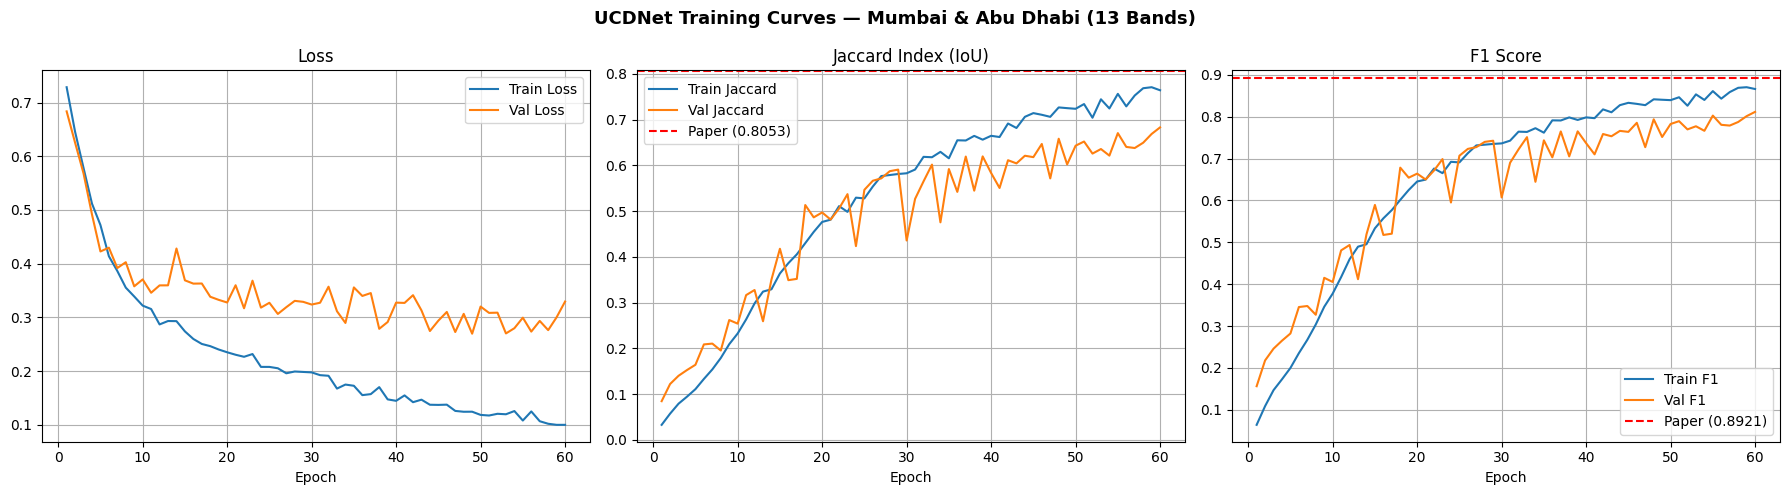

Plot saved!


In [ ]:
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Jaccard
axes[1].plot(epochs, history['train_jaccard'], label='Train Jaccard')
axes[1].plot(epochs, history['val_jaccard'],   label='Val Jaccard')
axes[1].axhline(y=0.8053, color='r', linestyle='--', label='Paper (0.8053)')
axes[1].set_title('Jaccard Index (IoU)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

# F1
axes[2].plot(epochs, history['train_f1'], label='Train F1')
axes[2].plot(epochs, history['val_f1'],   label='Val F1')
axes[2].axhline(y=0.8921, color='r', linestyle='--', label='Paper (0.8921)')
axes[2].set_title('F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('UCDNet Training Curves — Mumbai & Abu Dhabi (13 Bands)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

### 10. Train for 40 more epochs

In [ ]:
# Continue training from where we left off (model already loaded)
EXTRA_EPOCHS = 40
start_epoch  = EPOCHS + 1  # starts from 61

print("Continuing Training from Epoch {}...".format(start_epoch))
print("="*70)

for epoch in range(start_epoch, start_epoch + EXTRA_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader,
                                    optimizer, criterion, device, epoch)
    val_metrics   = validate(model, val_loader,
                             criterion, device, epoch)

    scheduler.step(val_metrics['jaccard'])

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_jaccard'].append(train_metrics['jaccard'])
    history['val_jaccard'].append(val_metrics['jaccard'])
    history['train_f1'].append(train_metrics['f1'])
    history['val_f1'].append(val_metrics['f1'])

    if val_metrics['jaccard'] > best_jaccard:
        best_jaccard = val_metrics['jaccard']
        torch.save(model.state_dict(), 'ucdnet_best.pth')
        saved = '✅ Saved'
    else:
        saved = ''

    print("Epoch [{:02d}/{}] "
          "Loss: {:.4f}/{:.4f} | "
          "J: {:.4f}/{:.4f} | "
          "F1: {:.4f}/{:.4f} {}"
          .format(epoch, start_epoch + EXTRA_EPOCHS - 1,
                  train_metrics['loss'], val_metrics['loss'],
                  train_metrics['jaccard'], val_metrics['jaccard'],
                  train_metrics['f1'], val_metrics['f1'],
                  saved))

print("="*70)
print("Best Val Jaccard so far: {:.4f}".format(best_jaccard))

Continuing Training from Epoch 61...
Epoch [61/100] Loss: 0.0998/0.2712 | J: 0.7787/0.6737 | F1: 0.8756/0.8050 
Epoch [62/100] Loss: 0.0991/0.3064 | J: 0.7586/0.6502 | F1: 0.8627/0.7881 
Epoch [63/100] Loss: 0.1045/0.2940 | J: 0.7614/0.6692 | F1: 0.8645/0.8018 
Epoch [64/100] Loss: 0.0990/0.2921 | J: 0.7780/0.6775 | F1: 0.8751/0.8077 
Epoch [65/100] Loss: 0.0970/0.2720 | J: 0.7682/0.6570 | F1: 0.8689/0.7930 
Epoch [66/100] Loss: 0.0960/0.2890 | J: 0.7779/0.6749 | F1: 0.8751/0.8059 
Epoch [67/100] Loss: 0.0938/0.2968 | J: 0.7740/0.6800 | F1: 0.8726/0.8095 
Epoch [68/100] Loss: 0.0923/0.2931 | J: 0.7806/0.6541 | F1: 0.8768/0.7909 
Epoch [69/100] Loss: 0.0937/0.3113 | J: 0.7819/0.6727 | F1: 0.8776/0.8043 
Epoch [70/100] Loss: 0.0984/0.2917 | J: 0.7832/0.6463 | F1: 0.8784/0.7851 
Epoch [71/100] Loss: 0.0915/0.2958 | J: 0.7815/0.6570 | F1: 0.8773/0.7930 
Epoch [72/100] Loss: 0.0996/0.2831 | J: 0.7908/0.6866 | F1: 0.8832/0.8142 ✅ Saved
Epoch [73/100] Loss: 0.0935/0.3216 | J: 0.7815/0.6703 | 

### 11. Test Set Evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load('ucdnet_best.pth'))
model.eval()

all_preds   = []
all_targets = []

with torch.no_grad():
    for img1, img2, labels in test_loader:
        img1    = img1.to(device)
        img2    = img2.to(device)
        outputs = model(img1, img2)
        all_preds.append(outputs.cpu())
        all_targets.append(labels)

all_preds   = torch.cat(all_preds,   dim=0)
all_targets = torch.cat(all_targets, dim=0)

test_metrics = compute_metrics(all_preds, all_targets)

print("="*50)
print("      TEST SET EVALUATION RESULTS")
print("="*50)
print("Jaccard Index (IoU) : {:.4f}".format(test_metrics['jaccard']))
print("F1 Score            : {:.4f}".format(test_metrics['f1']))
print("Accuracy            : {:.4f}".format(test_metrics['accuracy']))
print("="*50)
print("Paper Jaccard       :  0.8053")
print("Paper F1            :  0.8921")
print("="*50)

      TEST SET EVALUATION RESULTS
Jaccard Index (IoU) : 0.7003
F1 Score            : 0.8237
Accuracy            : 0.9860
Paper Jaccard       :  0.8053
Paper F1            :  0.8921


### 12. Visualize Predictions

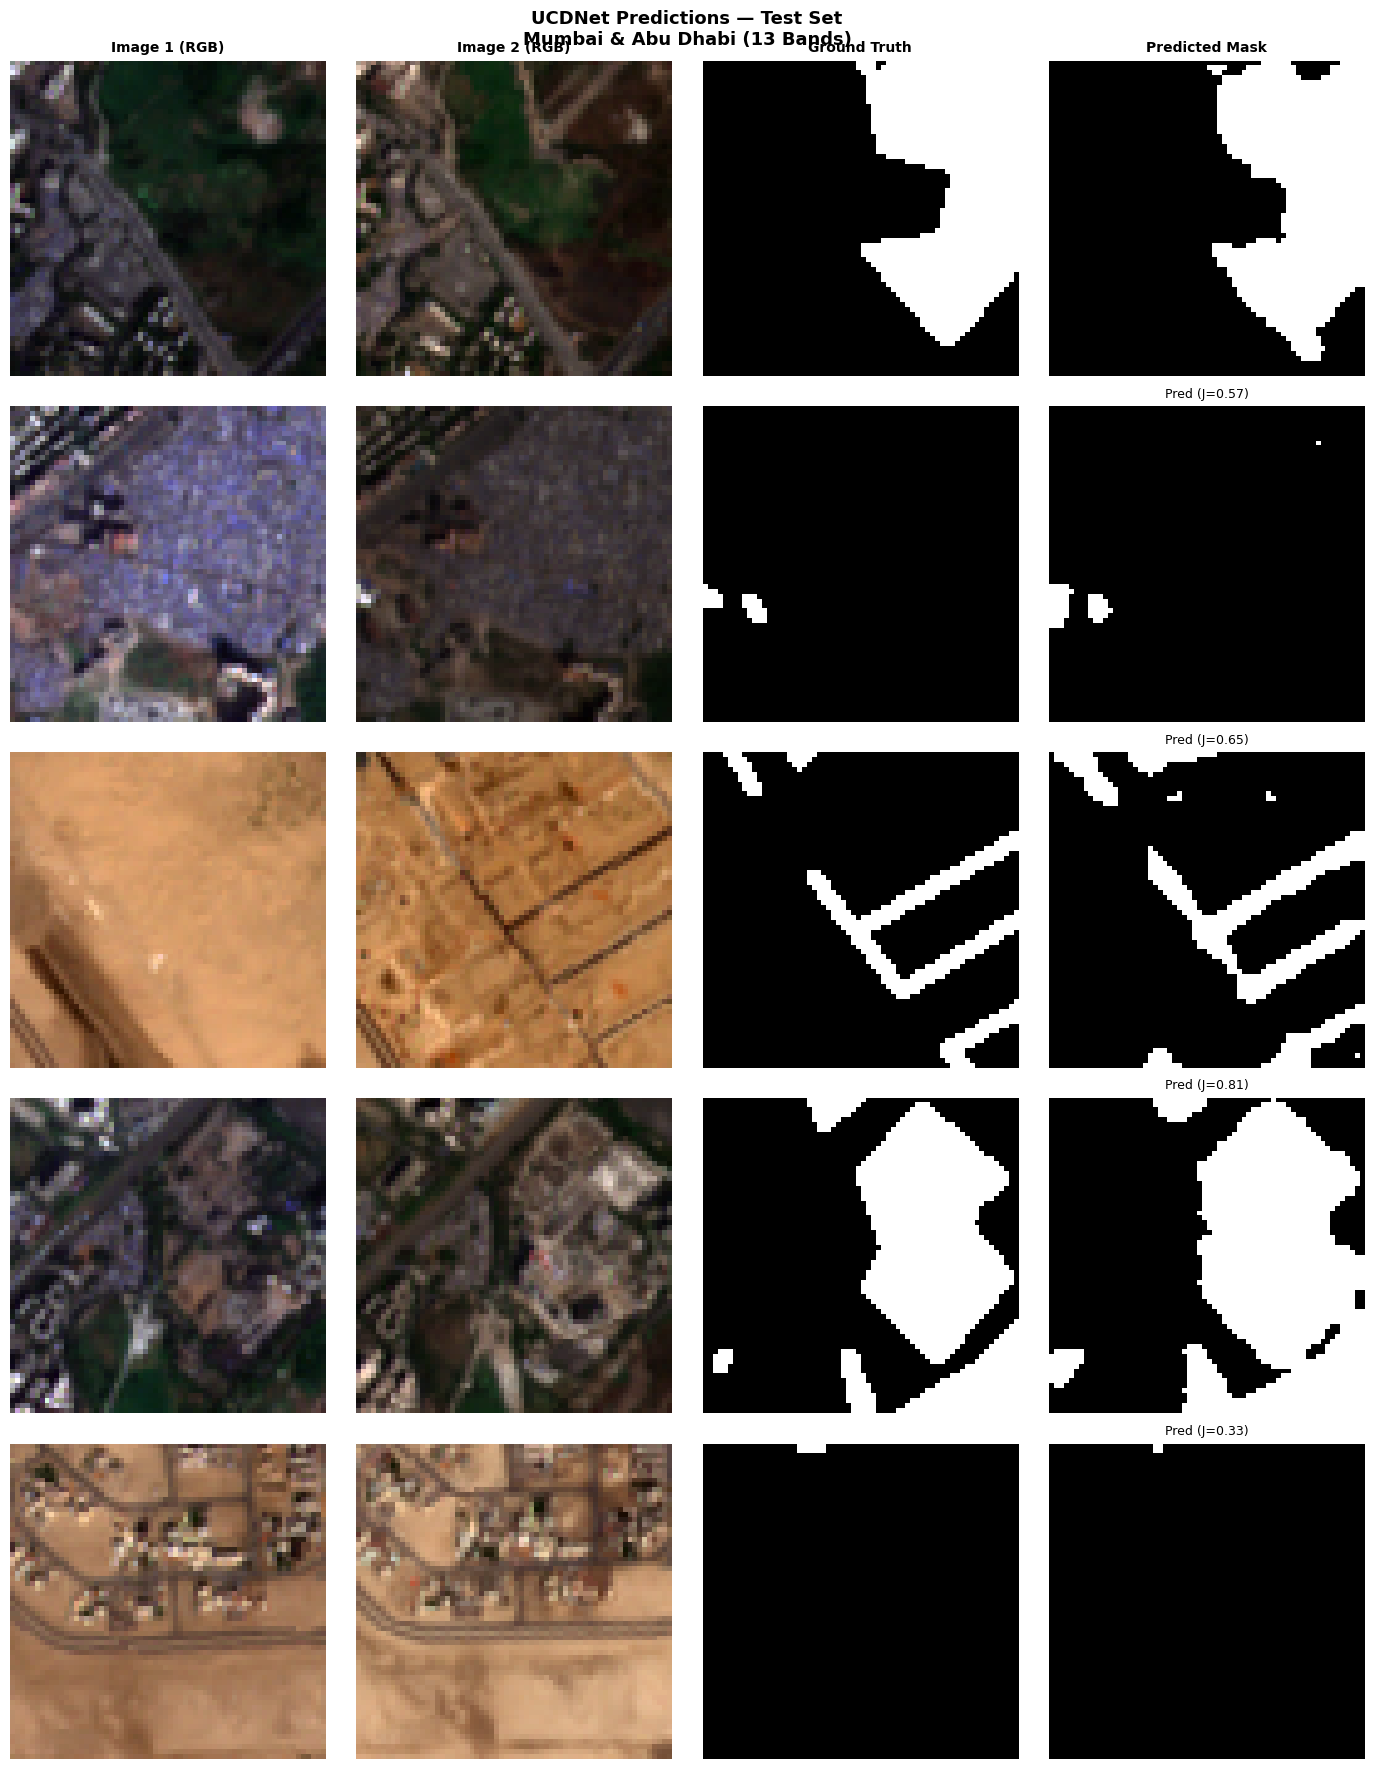

Saved!


In [ ]:
model.load_state_dict(torch.load('ucdnet_best.pth'))
model.eval()

# Get one batch from test loader
img1_batch, img2_batch, label_batch = next(iter(test_loader))
with torch.no_grad():
    outputs = model(img1_batch.to(device), img2_batch.to(device))
pred_batch = torch.argmax(outputs, dim=1).cpu()

# Plot 5 samples
fig, axes = plt.subplots(5, 4, figsize=(14, 18))
cols = ['Image 1 (RGB)', 'Image 2 (RGB)', 'Ground Truth', 'Predicted Mask']

for i in range(5):
    # RGB from bands [3,2,1]
    rgb1 = img1_batch[i][[3,2,1]].permute(1,2,0).numpy()
    rgb2 = img2_batch[i][[3,2,1]].permute(1,2,0).numpy()
    rgb1 = (rgb1 - rgb1.min()) / (rgb1.max() - rgb1.min() + 1e-7)
    rgb2 = (rgb2 - rgb2.min()) / (rgb2.max() - rgb2.min() + 1e-7)

    gt   = label_batch[i].numpy()
    pred = pred_batch[i].numpy()

    axes[i][0].imshow(rgb1)
    axes[i][1].imshow(rgb2)
    axes[i][2].imshow(gt,   cmap='gray')
    axes[i][3].imshow(pred, cmap='gray')

    # Jaccard per sample
    j = jaccard_score(gt.flatten(), pred.flatten(),
                      pos_label=1, zero_division=0)
    axes[i][3].set_title('Pred (J={:.2f})'.format(j), fontsize=9)

    for j_ax, col in enumerate(cols):
        if i == 0:
            axes[i][j_ax].set_title(col, fontsize=10, fontweight='bold')
        axes[i][j_ax].axis('off')

plt.suptitle('UCDNet Predictions — Test Set\nMumbai & Abu Dhabi (13 Bands)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### 13. Save Final Model + Summary

In [ ]:
import json

# Save final model
torch.save(model.state_dict(), 'ucdnet_final_100epochs.pth')

# Save history
with open('training_history.json', 'w') as f:
    json.dump(history, f)

# Final summary
print("="*55)
print("         UCDNET — FINAL SUMMARY")
print("="*55)
print("Dataset  : OSCD — Mumbai & Abu Dhabi")
print("Bands    : 13 (all Sentinel-2 bands)")
print("Patches  : Train={} | Val={} | Test={}".format(
      len(train_dataset), len(val_dataset), len(test_dataset)))
print("Patch Size: 64×64")
print("Epochs   : 100")
print("-"*55)
print("TEST RESULTS:")
print("  Jaccard (IoU) : {:.4f}  (Paper: 0.8053)".format(test_metrics['jaccard']))
print("  F1 Score      : {:.4f}  (Paper: 0.8921)".format(test_metrics['f1']))
print("  Accuracy      : {:.4f}  (Paper: 0.9930)".format(test_metrics['accuracy']))
print("-"*55)
print("MODEL:")
print("  Parameters    : 1,031,282")
print("  Best Val J    : {:.4f}".format(best_jaccard))
print("="*55)
print("Files saved:")
print("  ucdnet_best.pth")
print("  ucdnet_final_100epochs.pth")
print("  training_curves.png")
print("  predictions.png")
print("  training_history.json")

         UCDNET — FINAL SUMMARY
Dataset  : OSCD — Mumbai & Abu Dhabi
Bands    : 13 (all Sentinel-2 bands)
Patches  : Train=245 | Val=53 | Test=53
Patch Size: 64×64
Epochs   : 100
-------------------------------------------------------
TEST RESULTS:
  Jaccard (IoU) : 0.7003  (Paper: 0.8053)
  F1 Score      : 0.8237  (Paper: 0.8921)
  Accuracy      : 0.9860  (Paper: 0.9930)
-------------------------------------------------------
MODEL:
  Parameters    : 1,031,282
  Best Val J    : 0.6932
Files saved:
  ucdnet_best.pth
  ucdnet_final_100epochs.pth
  training_curves.png
  predictions.png
  training_history.json


### 14. Download the model

In [ ]:
from google.colab import files

# Download best model
files.download('ucdnet_best.pth')

# Download training curves
files.download('training_curves.png')

# Download predictions
files.download('predictions.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>